US Accidents (2016-2023)
This is a countrywide car accident dataset that covers 49 states of the USA. The accident data were collected from February 2016 to March 2023, using multiple APIs that provide streaming traffic incident (or event) data. These APIs broadcast traffic data captured by various entities, including the US and state departments of transportation, law enforcement agencies, traffic cameras, and traffic sensors within the road networks. The dataset currently contains approximately 7.7 million accident records. For more information about this dataset, please visit here.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline
pd.set_option('display.max_columns', None)

In [3]:
dff = pd.read_csv('US_Accidents_March23.csv')
dff.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.9,NaN,91.0,29.68,10.0,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.9,NaN,100.0,29.65,10.0,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.0,33.3,100.0,29.67,10.0,SW,3.5,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.1,31.0,96.0,29.64,9.0,SW,4.6,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.0,33.3,89.0,29.65,6.0,SW,3.5,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


**1-Preprocessing****** . 


**> 1- Take Copy of data> 2- Check Data Shape> 3- Check Duplicated Data> 4- Check Data Columns**


In [4]:
df = dff.copy()


print(f'Shape: {df.shape}')

Shape: (7728394, 46)


In [5]:
print(f'Duplicates: {df.duplicated().sum()}')

print(df.columns)

Duplicates: 0
Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [7]:
# Show Different Data Type and Convert it to to do List

numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
boolean_features = df.select_dtypes(include=['bool']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
datetime_features = df.select_dtypes(include=['datetime64']).columns.tolist()

print("Numerical features ({}): {}".format(len(numeric_features), numeric_features))
print()

print("Boolean features ({}): {}".format(len(boolean_features), boolean_features))
print()

print("Categorical features ({}): {}".format(len(categorical_features), categorical_features))
print()

print("Datetime features ({}): {}".format(len(datetime_features), datetime_features))

Numerical features (13): ['Severity', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

Boolean features (13): ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']

Categorical features (20): ['ID', 'Source', 'Start_Time', 'End_Time', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']

Datetime features (0): []


In [8]:
# Show Missing Percentage in each columns
missing_percentage = (df.isna().sum() / len(df)) * 100
missing_percentage = missing_percentage.sort_values(ascending=False)

print(missing_percentage.round(2).astype(str) + " %")

missing_percentage = (df.isna().sum()/len(df))*100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values()

End_Lng                  44.03 %
End_Lat                  44.03 %
Precipitation(in)        28.51 %
Wind_Chill(F)            25.87 %
Wind_Speed(mph)           7.39 %
Visibility(mi)            2.29 %
Wind_Direction            2.27 %
Humidity(%)               2.25 %
Weather_Condition         2.24 %
Temperature(F)            2.12 %
Pressure(in)              1.82 %
Weather_Timestamp         1.56 %
Sunrise_Sunset             0.3 %
Civil_Twilight             0.3 %
Astronomical_Twilight      0.3 %
Nautical_Twilight          0.3 %
Airport_Code              0.29 %
Street                    0.14 %
Timezone                   0.1 %
Zipcode                   0.02 %
City                       0.0 %
Description                0.0 %
ID                         0.0 %
Distance(mi)               0.0 %
Start_Lng                  0.0 %
Source                     0.0 %
Severity                   0.0 %
Start_Time                 0.0 %
End_Time                   0.0 %
Start_Lat                  0.0 %
County    

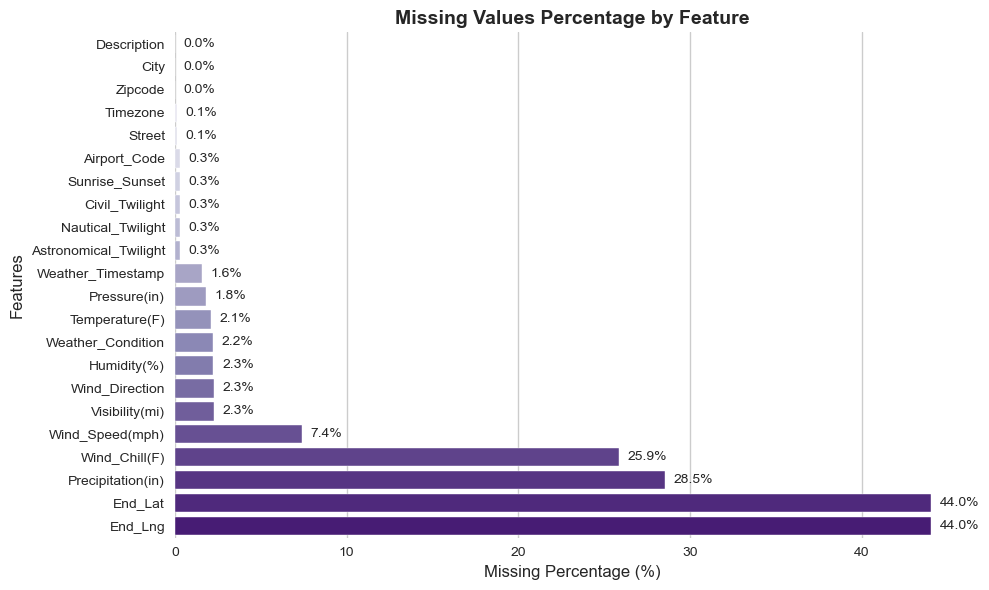

In [9]:
missing_percentage = (df.isna().sum()/len(df))*100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values()

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

colors = sns.color_palette("Purples", n_colors=len(missing_percentage))

ax = sns.barplot(
    x=missing_percentage.values,
    y=missing_percentage.index,
    palette=colors
)

for i, v in enumerate(missing_percentage.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=10)

plt.xlabel("Missing Percentage (%)", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.title("Missing Values Percentage by Feature", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

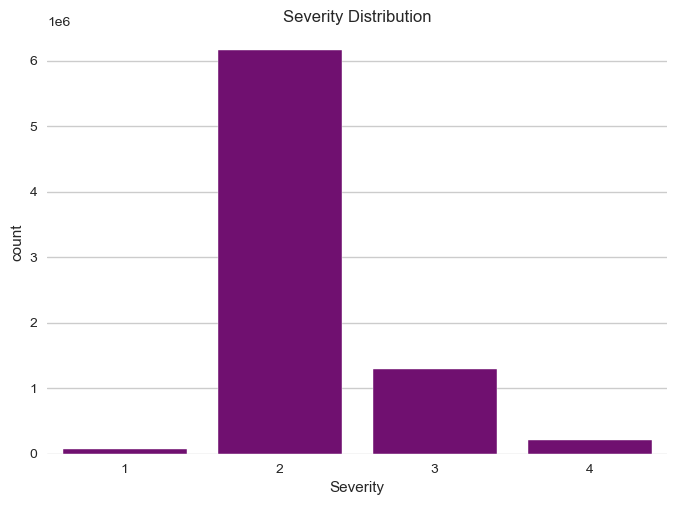

Severity
2    0.796670
3    0.168125
4    0.026488
1    0.008717
Name: proportion, dtype: float64


In [10]:
# Target Distribution (Severity)
sns.countplot(x='Severity', data=df,color='purple')
plt.title("Severity Distribution")
plt.show()

print(df['Severity'].value_counts(normalize=True))

**EDA (some Columns Need to drop It we can make EDA Before dropping****)**

In [11]:
# Show Distribution of Categories of Some Columns
cat_cols = df.select_dtypes(include='object').columns

print(len(cat_cols))
cat_cols

20


Index(['ID', 'Source', 'Start_Time', 'End_Time', 'Description', 'Street',
       'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Wind_Direction',
       'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight',
       'Nautical_Twilight', 'Astronomical_Twilight'],
      dtype='object')

In [12]:
for col in cat_cols:
    print(col, df[col].nunique())

ID 7728394
Source 3
Start_Time 6131796
End_Time 6705355
Description 3761578
Street 336306
City 13678
County 1871
State 49
Zipcode 825094
Country 1
Timezone 4
Airport_Code 2045
Weather_Timestamp 941331
Wind_Direction 24
Weather_Condition 144
Sunrise_Sunset 2
Civil_Twilight 2
Nautical_Twilight 2
Astronomical_Twilight 2


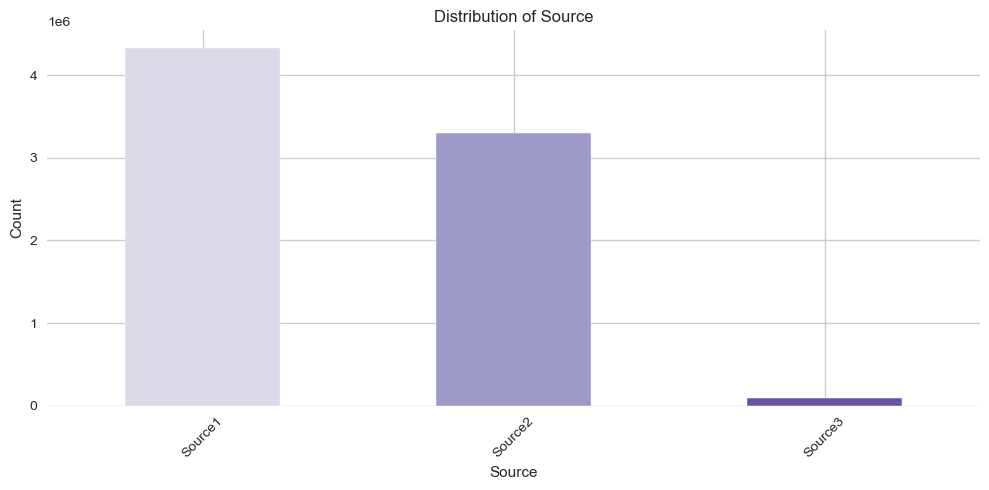

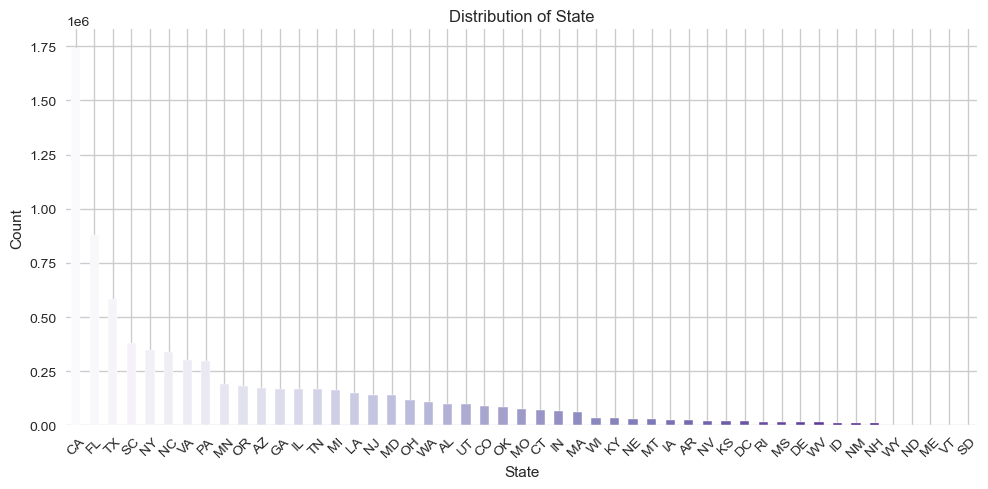

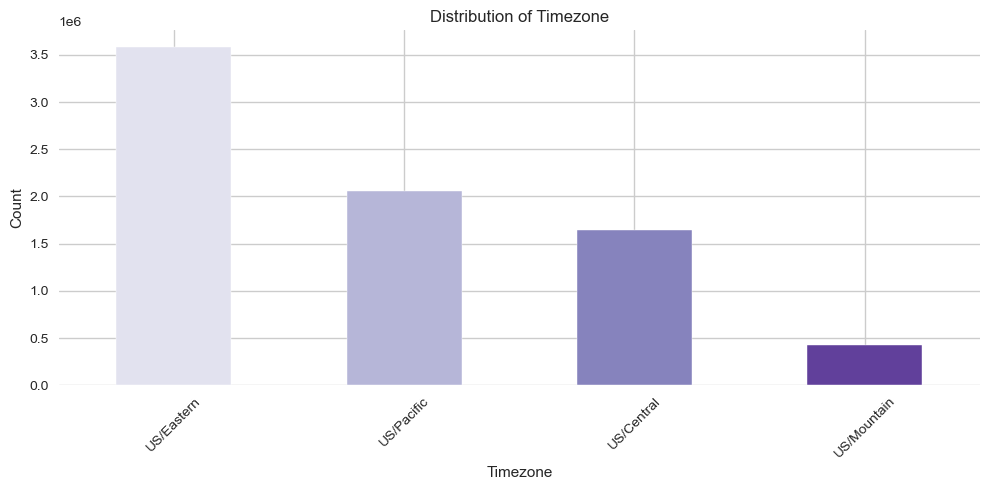

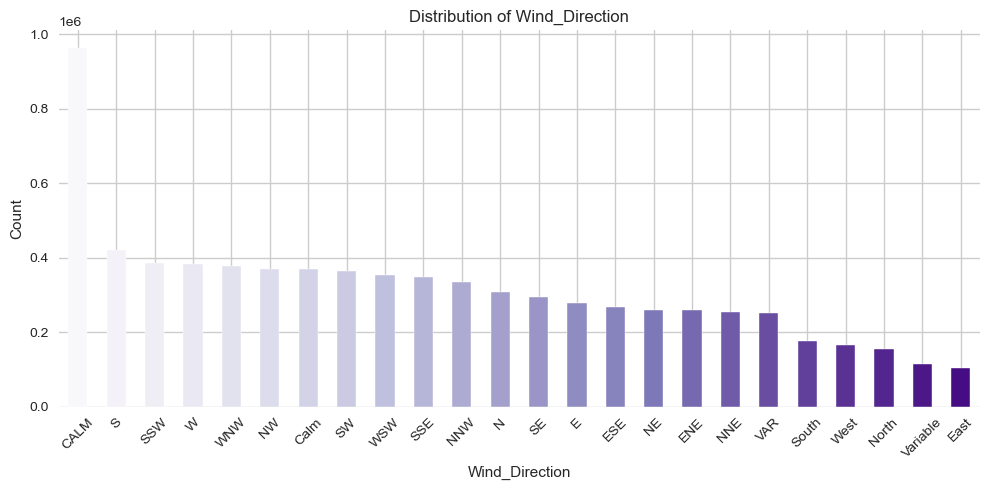

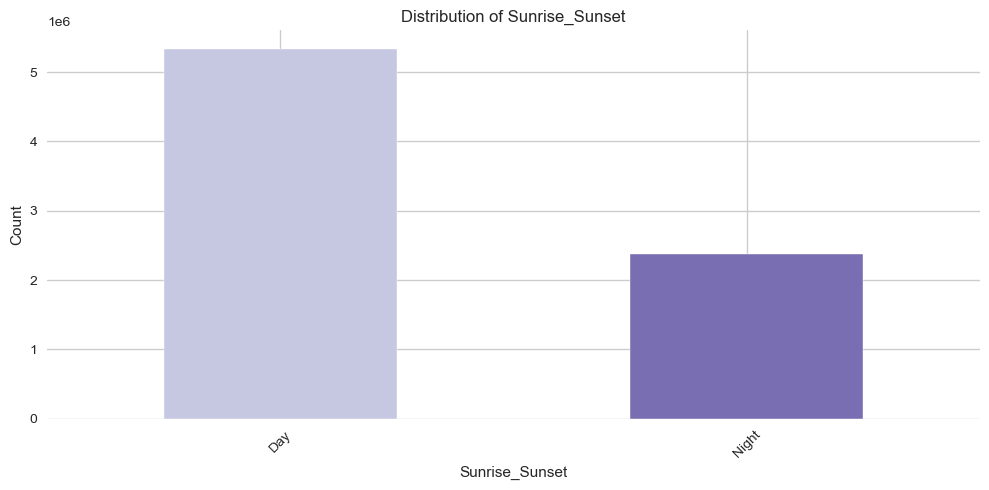

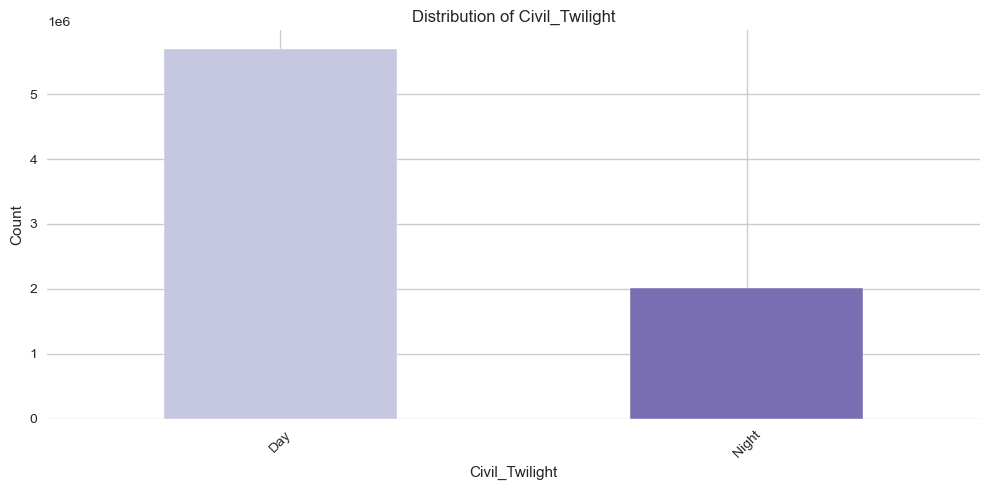

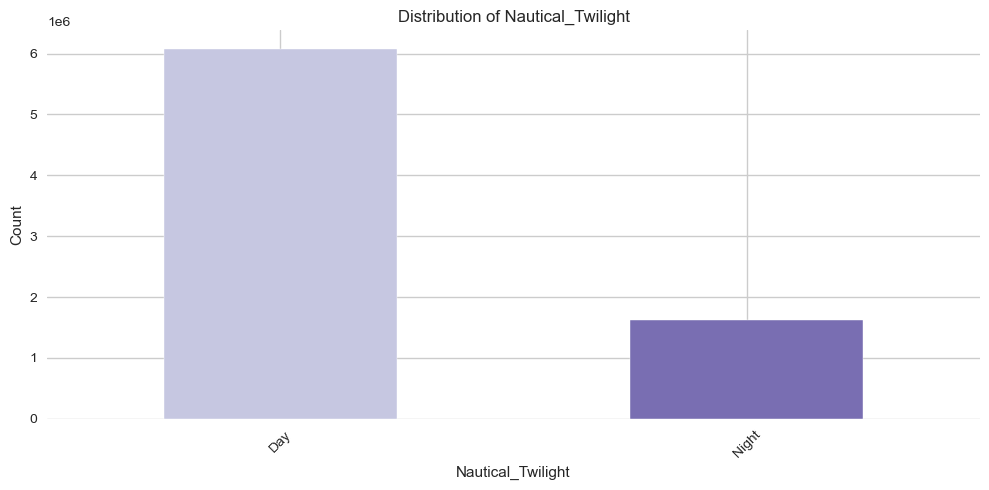

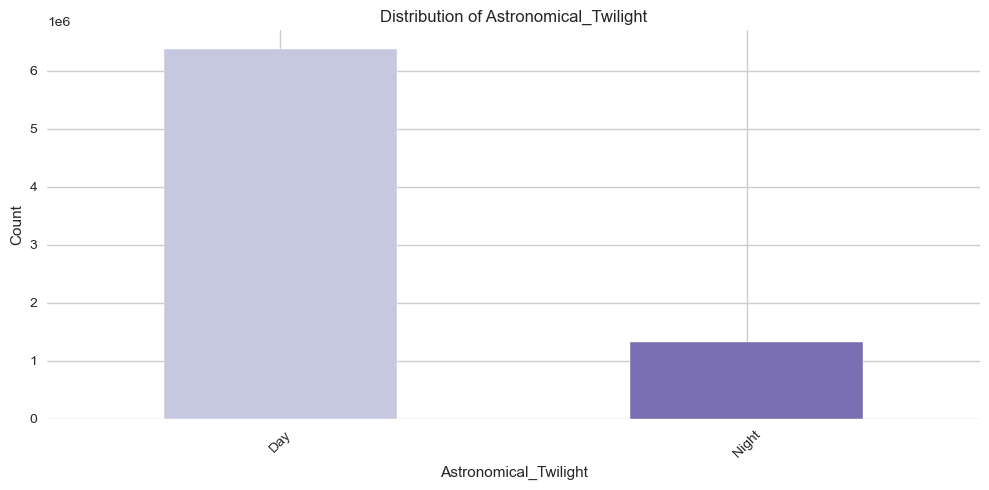

In [13]:
# Show Distribution of Some Columns
ignore_cols = [
    'ID','Description','Street','Zipcode',
    'Airport_Code','Country','Number'
]

cat_cols = [
    col for col in df.select_dtypes(include='object').columns
    if col not in ignore_cols and df[col].nunique() < 50
]

for col in cat_cols:
    
    plt.figure(figsize=(10,5))
    
    counts = df[col].value_counts()
    
    colors = sns.color_palette("Purples", n_colors=len(counts))
    
    counts.plot(
        kind='bar',
        color=colors
    )
    
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

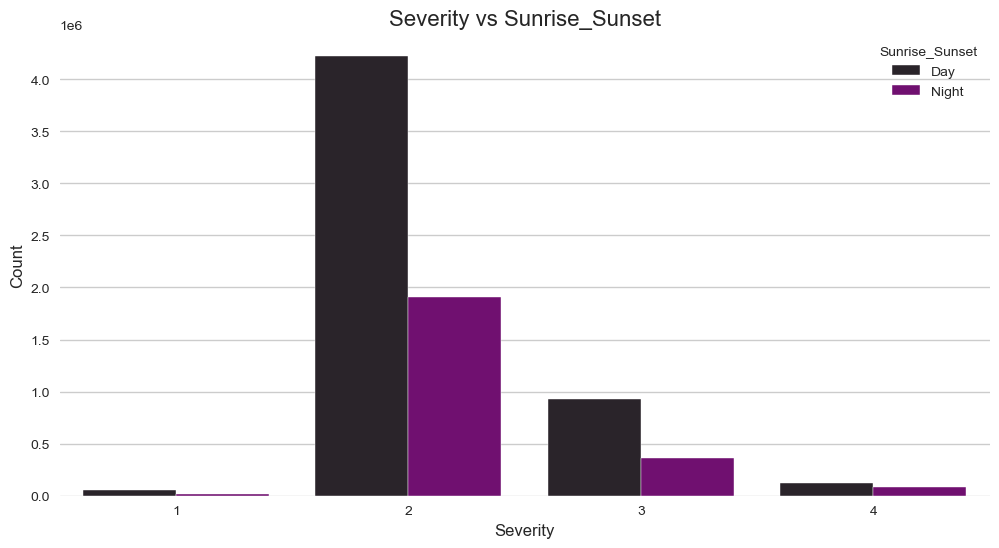

In [14]:
#Severity vs Weather
plt.figure(figsize=(12,6))

# Darker purple palette
colors = sns.dark_palette("purple", n_colors=df['Sunrise_Sunset'].nunique())

sns.countplot(
    data=df,
    x='Severity',
    hue='Sunrise_Sunset',
    palette=colors
)

plt.title("Severity vs Sunrise_Sunset", fontsize=16)
plt.xlabel("Severity", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

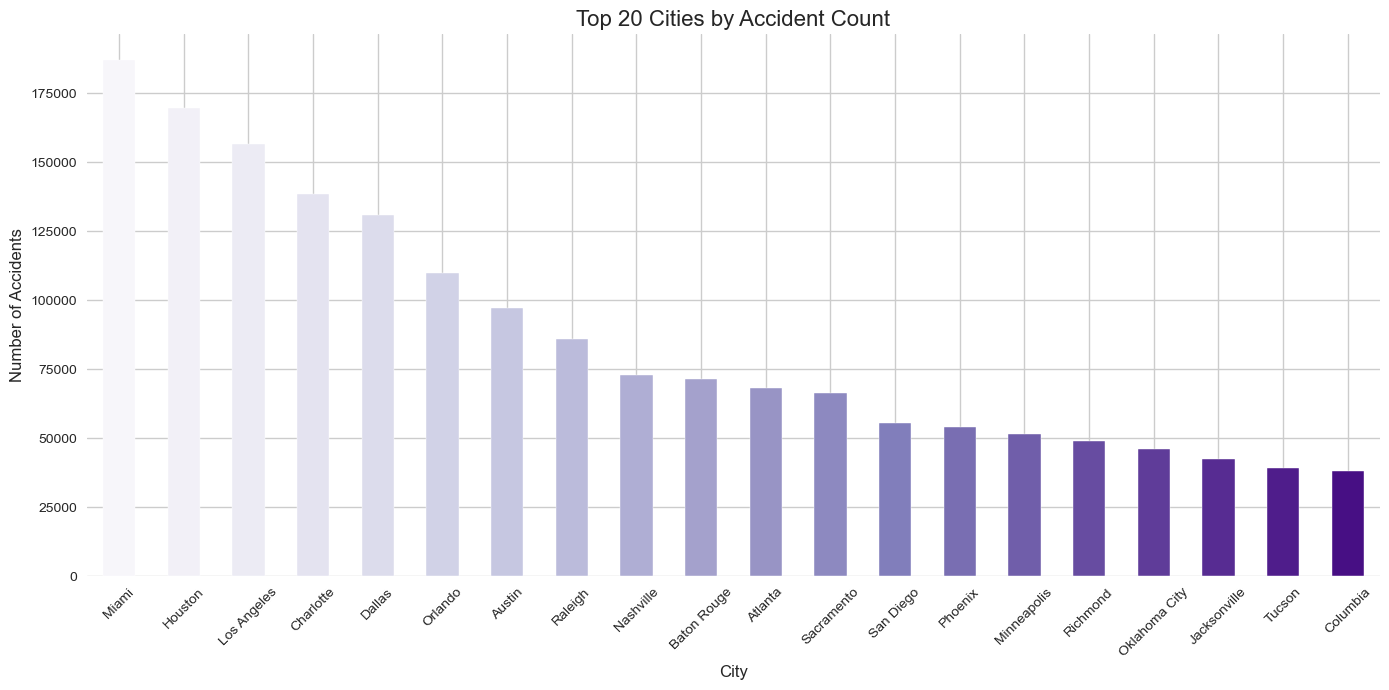

In [15]:
# Get Top 20 cities
top_cities = df['City'].value_counts().head(20)

# Create color palette with same number of colors
colors = sns.color_palette("Purples", n_colors=len(top_cities))

# Plot
plt.figure(figsize=(14,7))
top_cities.plot(kind='bar', color=colors)
plt.title("Top 20 Cities by Accident Count", fontsize=16)
plt.xlabel("City", fontsize=12)
plt.ylabel("Number of Accidents", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
#Severity vs Road Features
road_features = [
    'Amenity','Bump','Crossing','Give_Way','Junction',
    'No_Exit','Railway','Roundabout','Station','Stop',
    'Traffic_Calming','Traffic_Signal','Turning_Loop'
]

for col in road_features:
    print(col)
    print(pd.crosstab(df[col], df['Severity']))
    print("------")

Amenity
Severity      1        2        3       4
Amenity                                  
False     65987  6068089  1295307  202677
True       1379    88892     4030    2033
------
Bump
Severity      1        2        3       4
Bump                                     
False     67332  6153837  1299031  204680
True         34     3144      306      30
------
Crossing
Severity      1        2        3       4
Crossing                                 
False     48675  5363435  1251305  191216
True      18691   793546    48032   13494
------
Give_Way
Severity      1        2        3       4
Give_Way                                 
False     66817  6126858  1294598  203539
True        549    30123     4739    1171
------
Junction
Severity      1        2        3       4
Junction                                 
False     64239  5741842  1166841  184130
True       3127   415139   132496   20580
------
No_Exit
Severity      1        2        3       4
No_Exit                            

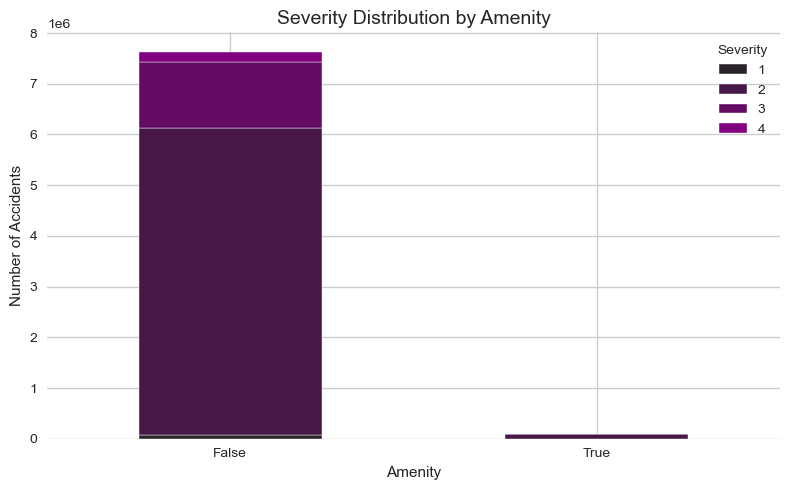

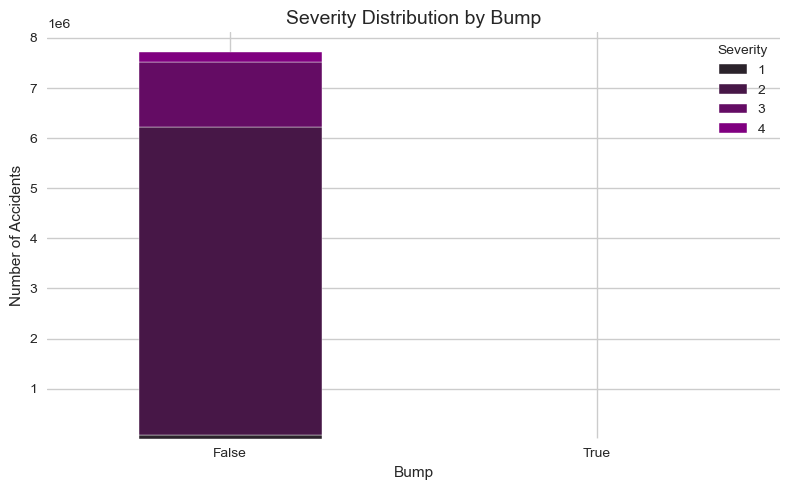

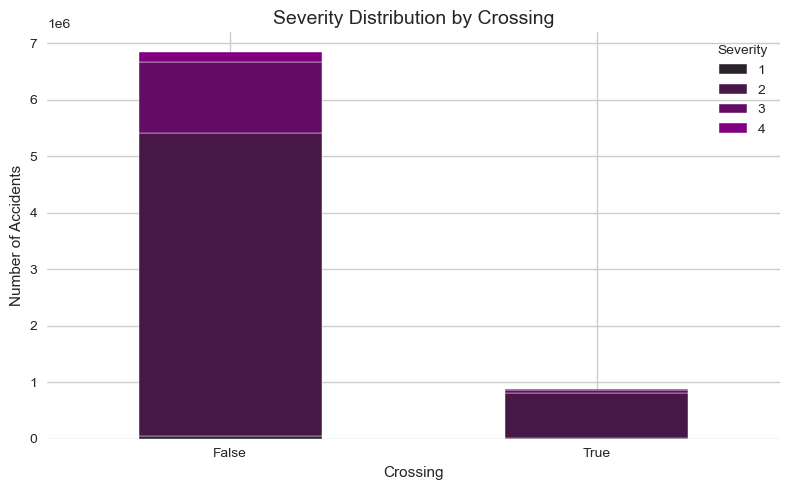

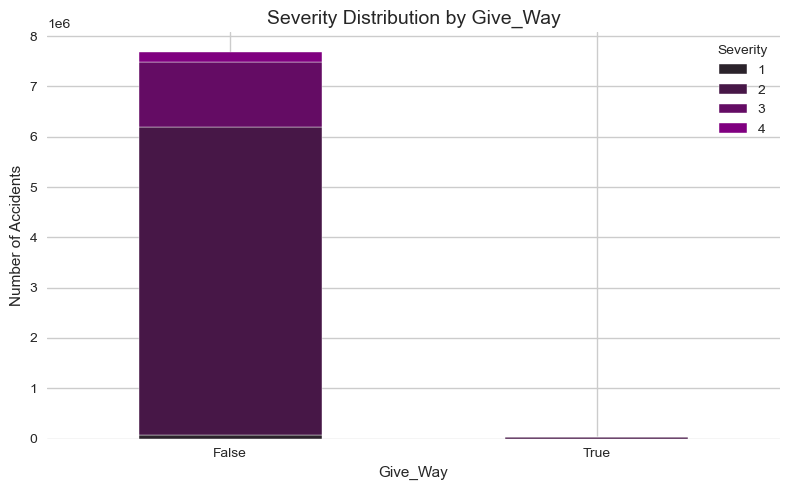

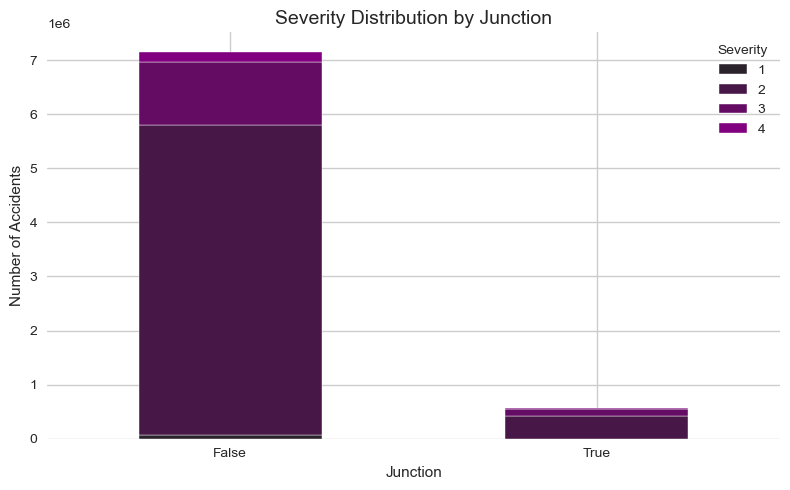

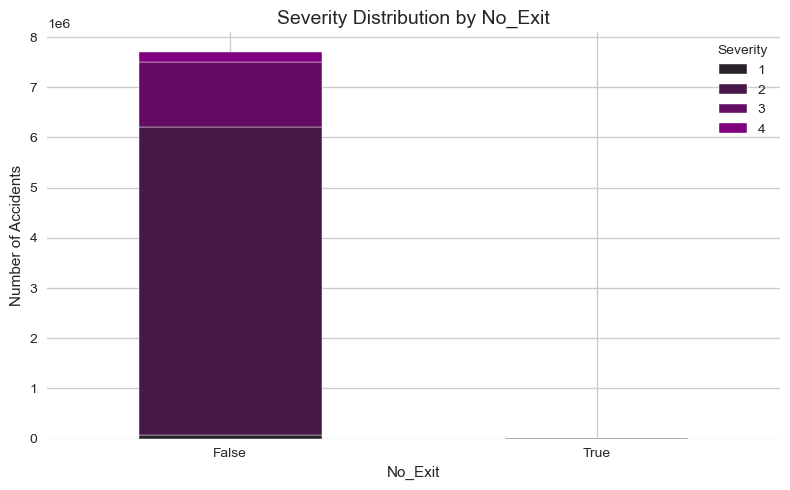

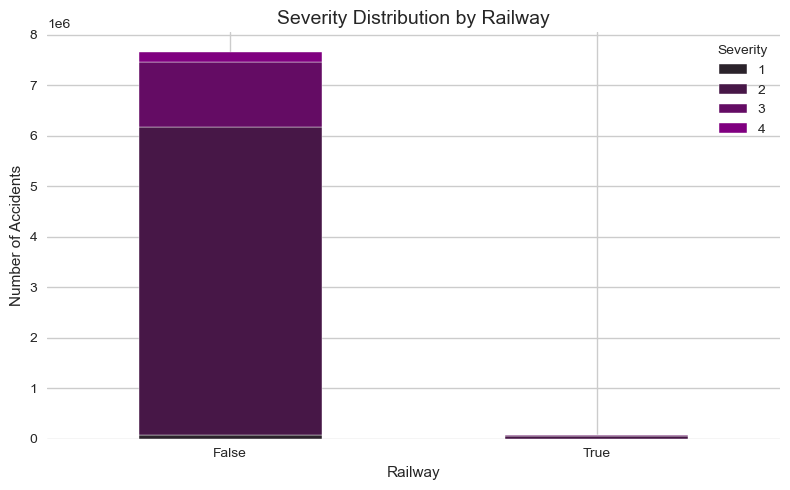

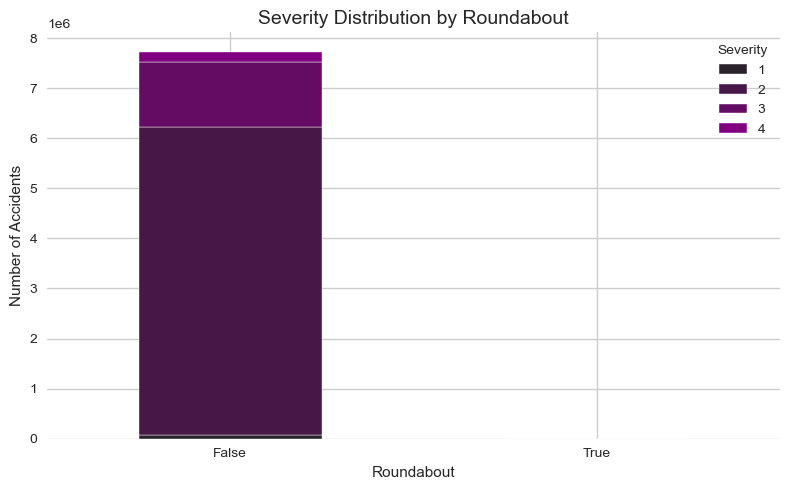

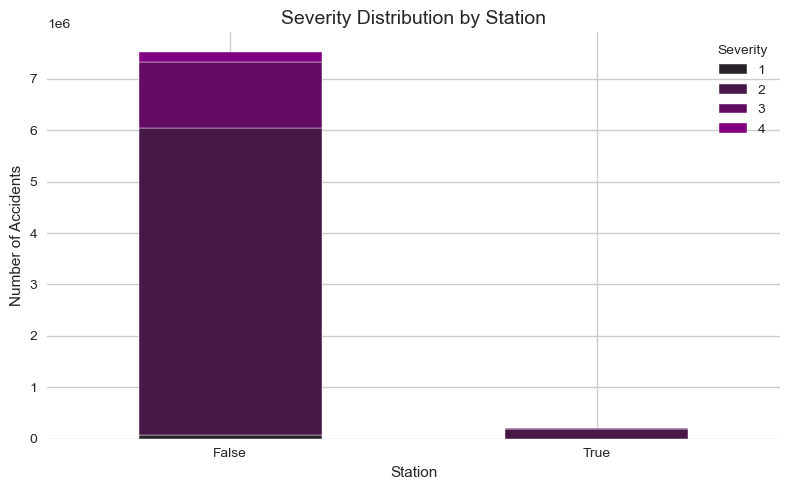

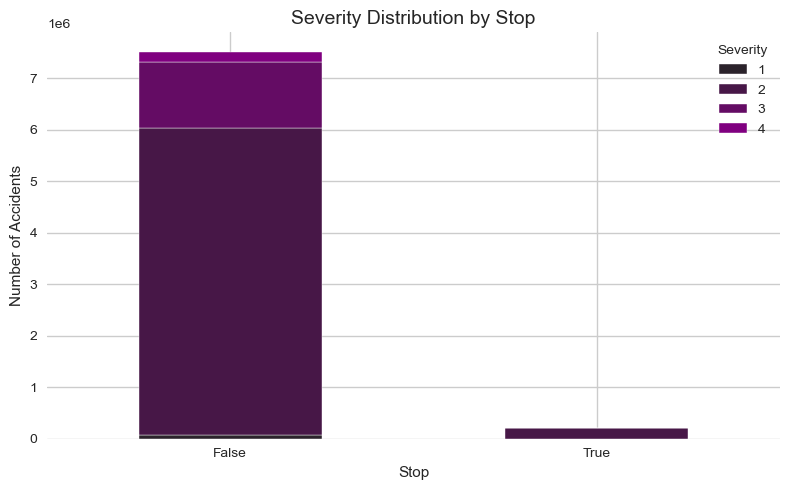

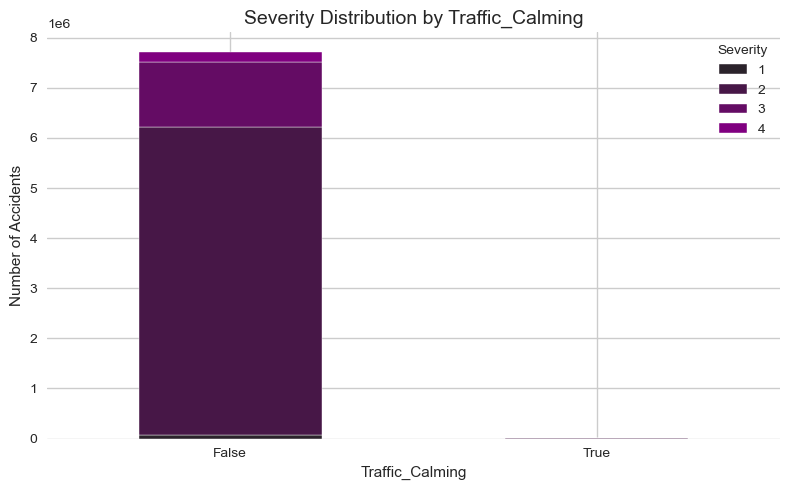

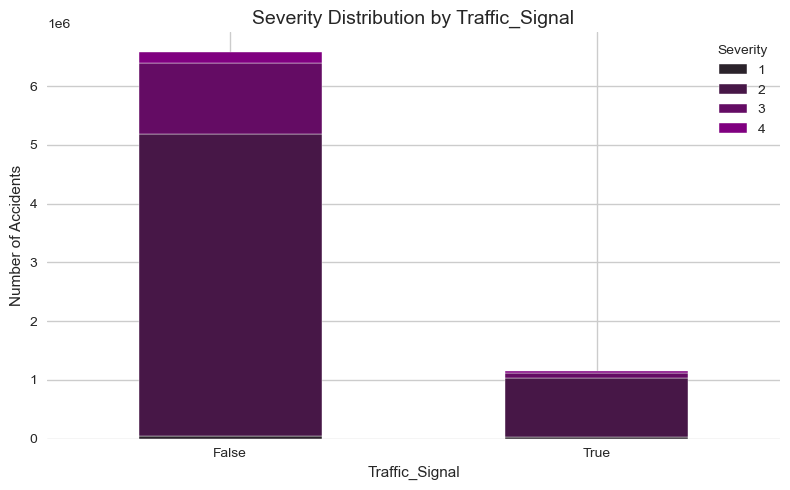

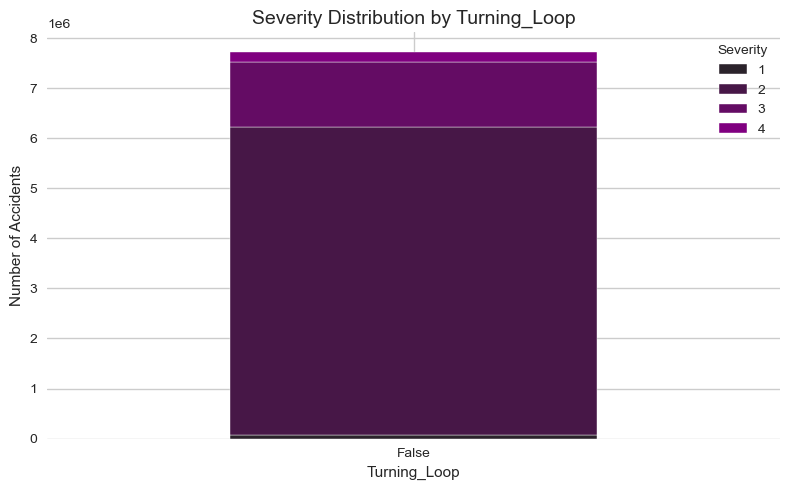

In [17]:
road_features = [
    'Amenity','Bump','Crossing','Give_Way','Junction',
    'No_Exit','Railway','Roundabout','Station','Stop',
    'Traffic_Calming','Traffic_Signal','Turning_Loop'
]

for col in road_features:
    plt.figure(figsize=(8,5))
    
    # Create crosstab
    ct = pd.crosstab(df[col], df['Severity'])
    
    # Dark purple palette (one color per Severity)
    colors = sns.dark_palette("purple", n_colors=ct.shape[1])
    
    # Plot stacked bar chart
    ct.plot(kind='bar', stacked=True, color=colors, ax=plt.gca())
    
    plt.title(f'Severity Distribution by {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Number of Accidents')
    plt.xticks(rotation=0)
    plt.legend(title='Severity')
    plt.tight_layout()
    plt.show()

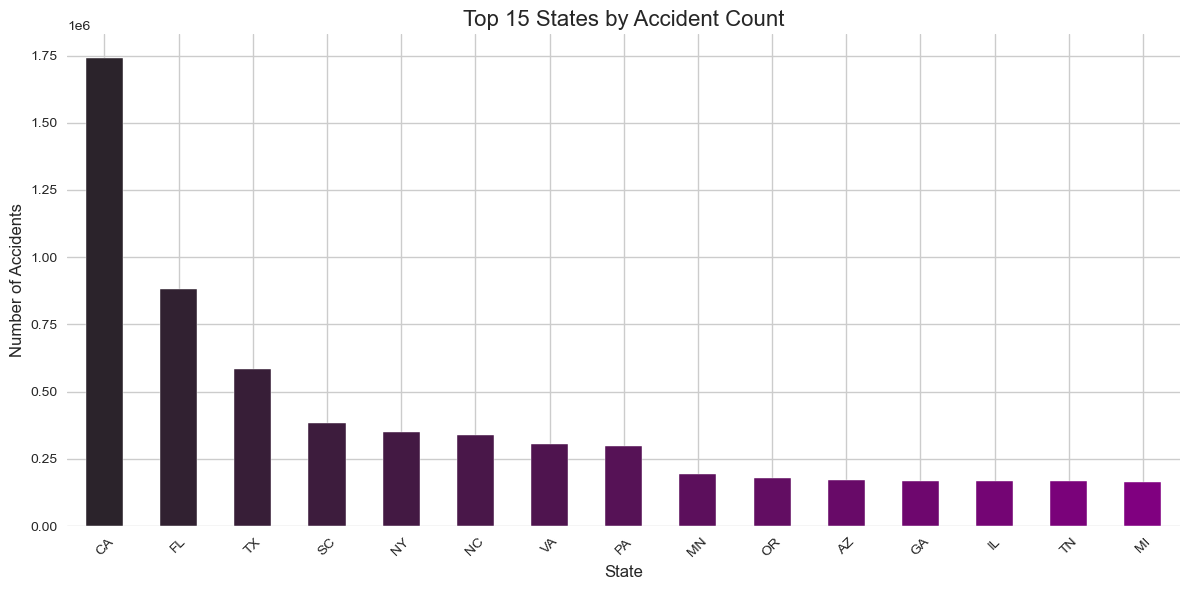

In [18]:
# Top 15 states by accident count
top_states = df['State'].value_counts().head(15)

# Dark purple palette (one color per bar)
colors = sns.dark_palette("purple", n_colors=len(top_states))

# Plot
plt.figure(figsize=(12,6))
top_states.plot(kind='bar', color=colors)
plt.title("Top 15 States by Accident Count", fontsize=16)
plt.xlabel("State", fontsize=12)
plt.ylabel("Number of Accidents", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# Convert the Date abd Time
df['Start_Date'] = df['Start_Time'].str.split(' ').str[0]
df['Start_Time_new'] = df['Start_Time'].str.split(' ').str[1]

df['End_Date'] = df['End_Time'].str.split(' ').str[0]
df['End_Time_New'] = df['End_Time'].str.split(' ').str[1]

df['Start_Date'] = pd.to_datetime(
    df['Start_Date'],
    format='%Y-%m-%d',
    errors='coerce'
)

df['End_Date'] = pd.to_datetime(
    df['End_Date'],
    format='%Y-%m-%d',
    errors='coerce'
)

df['End_Time_New'] = pd.to_datetime(df['End_Time_New'], errors='coerce')
df['Start_Time_new'] = pd.to_datetime(df['Start_Time_new'], errors='coerce')

In [20]:
# Check Missing Values in New Columns
df.isnull().sum()

ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Amenity                        0
Bump      

In [21]:
# Fill missing numerical values with median
numerical_cols = ["Wind_Speed(mph)", "Visibility(mi)", "Humidity(%)", "Temperature(F)", "Pressure(in)"]
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill missing categorical values with mode
categorical_cols = ["Wind_Direction", "Weather_Condition", "Sunrise_Sunset", "Nautical_Twilight", 
                    "Civil_Twilight", "Astronomical_Twilight", "Timezone", 
                    "Zipcode", "City", "County", "State", "Country"]
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify missing values are handled
print("Final Missing Value Check:", df.isnull().sum().sum())

Final Missing Value Check: 11161866


In [22]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'Start_Date', 'Start_Time_new', 'End_Date',
       'End_Time_New'],
      dtype='object')

In [23]:
df['Precipitation(in)'].describe()

count    5.524808e+06
mean     8.407210e-03
std      1.102246e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.647000e+01
Name: Precipitation(in), dtype: float64

In [24]:
# Define dry weather types
dry_conditions = ['Volcanic Ash', 'Sand', 'Dust Whirls', 'Heavy Smoke', 'Fog', 'Clear']

# Compute group medians for all Weather_Condition
group_medians = df.groupby('Weather_Condition')['Precipitation(in)'].median()

#  Fill dry conditions with 0
df.loc[df['Weather_Condition'].isin(dry_conditions) & df['Precipitation(in)'].isna(), 
       'Precipitation(in)'] = 0

#  Fill other missing values using group median
mask = df['Precipitation(in)'].isna()
df.loc[mask, 'Precipitation(in)'] = df.loc[mask, 'Weather_Condition'].map(group_medians)

# Fallback: fill any remaining NaN with overall median
df['Precipitation(in)'].fillna(df['Precipitation(in)'].median(), inplace=True)

# Check
print(df['Precipitation(in)'].isnull().sum())

0


In [25]:
df['Precipitation(in)'].describe()

count    7.728394e+06
mean     6.129970e-03
std      9.331003e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.647000e+01
Name: Precipitation(in), dtype: float64

In [26]:
mask = df['Wind_Chill(F)'].isna()
df.loc[mask, 'Wind_Chill(F)'] = (
    35.74 + 0.6215*df.loc[mask,'Temperature(F)'] 
    - 35.75*(df.loc[mask,'Wind_Speed(mph)']**0.16) 
    + 0.4275*df.loc[mask,'Temperature(F)']*(df.loc[mask,'Wind_Speed(mph)']**0.16)
)

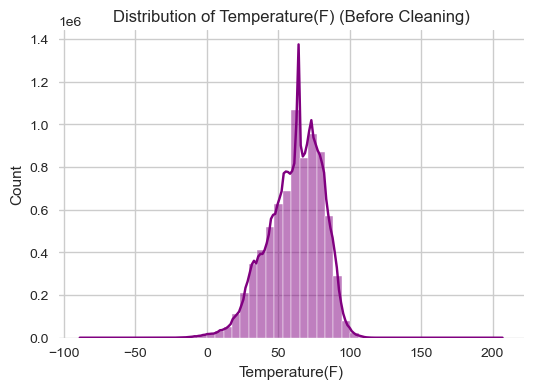

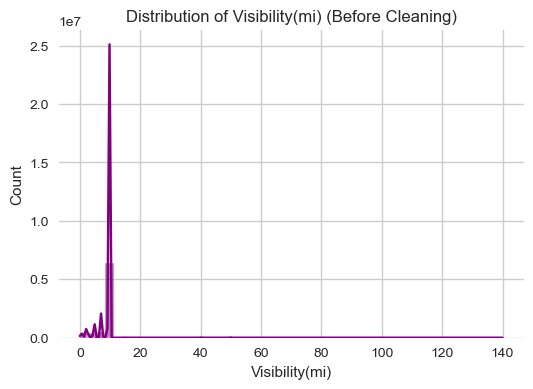

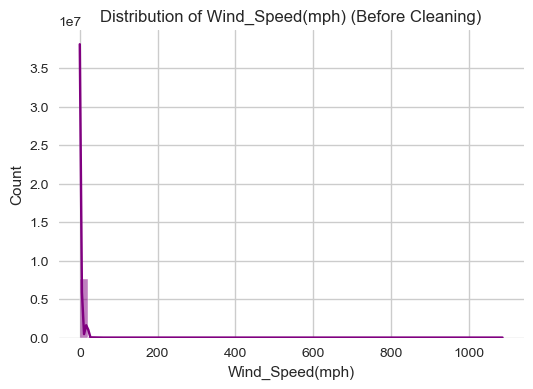

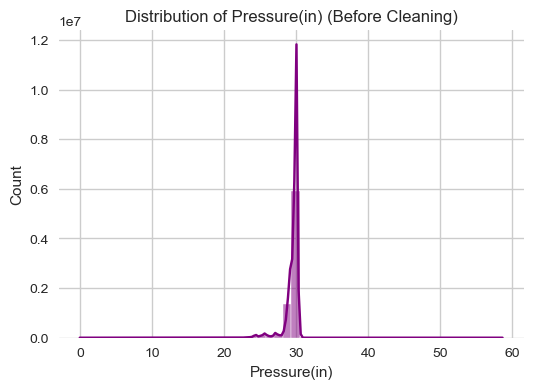

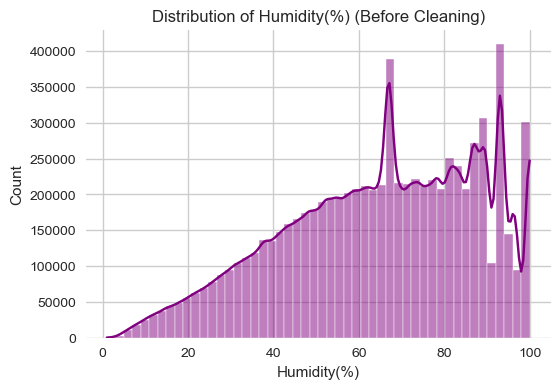

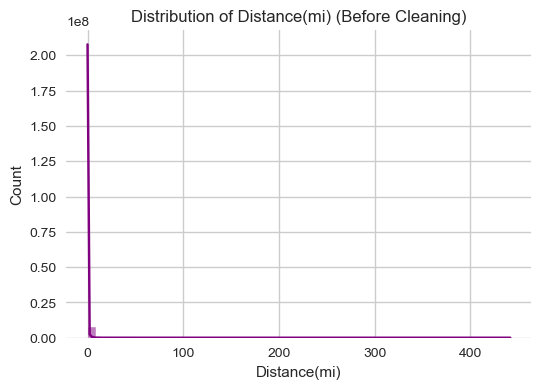

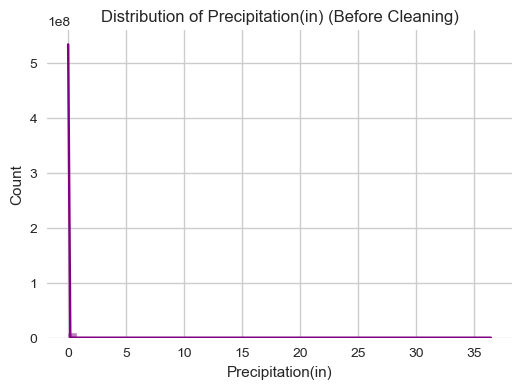

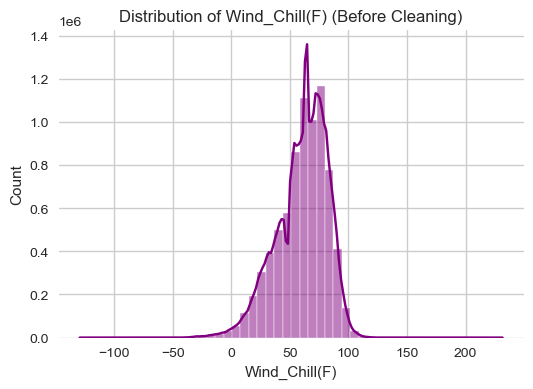

In [27]:
# Show Distribution of Numeric Columns to Check the Distriution Type
cols = [
    "Temperature(F)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Pressure(in)",
    "Humidity(%)",
    "Distance(mi)",
    "Precipitation(in)",
    'Wind_Chill(F)'
]

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=50, kde=True,color='purple')
    plt.title(f"Distribution of {col} (Before Cleaning)")
    plt.show()

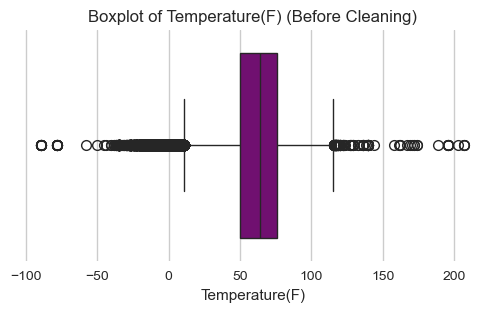

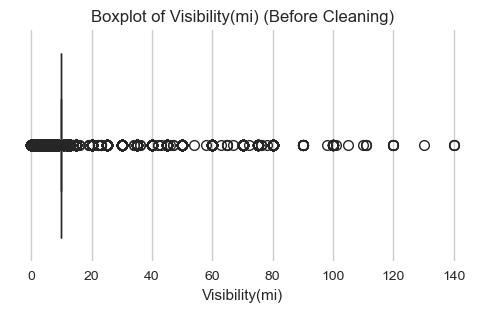

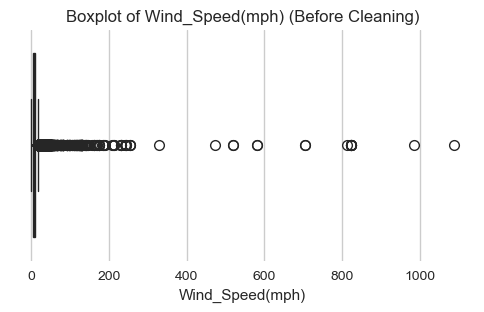

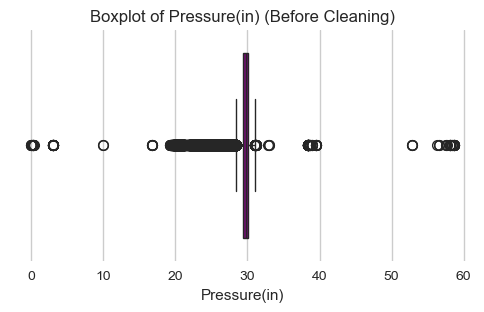

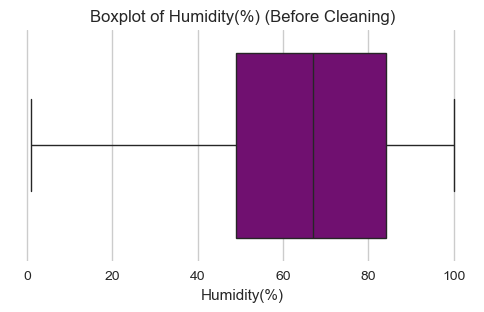

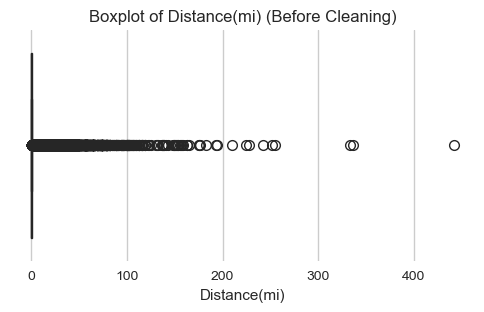

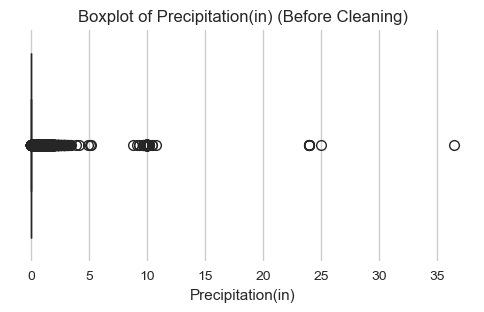

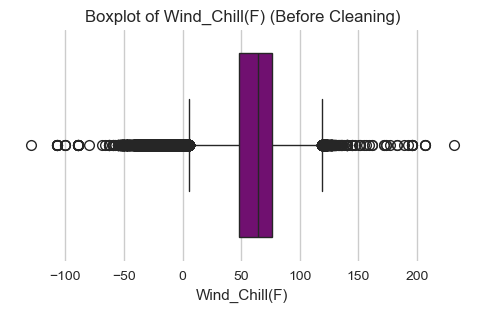

In [28]:
# Check Outliers
for col in cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col],color='purple')
    plt.title(f"Boxplot of {col} (Before Cleaning)")
    plt.show()

In [29]:
# Feature engineering using Start_Time_new_n
df['Start_Time_only'] = df['Start_Time_new'].dt.strftime('%H:%M:%S')
df['End_Time_only'] = df['End_Time_New'].dt.strftime('%H:%M:%S')
df['Hour_Start'] = df['Start_Time_new'].dt.hour
df['Minutes_Start'] = df['Start_Time_new'].dt.minute
df['Hour_End'] = df['End_Time_New'].dt.hour
df['Minutes_End'] = df['End_Time_New'].dt.minute
df['Day_of_Week'] = df['Start_Date'].dt.dayofweek
df['Month'] = df['Start_Date'].dt.month
df['Year'] = df['Start_Date'].dt.year
df['Accident_Duration_Hours'] = df['End_Time_New']-df['Start_Time_new']
df['Duration_Hours'] = (df['Accident_Duration_Hours'].dt.total_seconds() / 3600).round(2)
df['Duration_Minutes'] = (df['Accident_Duration_Hours'].dt.total_seconds() / 60).round(2)


# Rush hour: morning 7–9, evening 16–18
df['Rush_Hour'] = df['Hour_Start'].apply(lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 18) else 0)

In [30]:
# Dealing With Outliers 
df_clean = df.copy()

# Temperature
df_clean["Temperature(F)"] = df_clean["Temperature(F)"].clip(-20,120)

# Visibility
df_clean["Visibility(mi)"] = df_clean["Visibility(mi)"].clip(upper=20)

# Wind Speed
df_clean["Wind_Speed(mph)"] = df_clean["Wind_Speed(mph)"].clip(upper=60)

# Humidity
df_clean["Humidity(%)"] = df_clean["Humidity(%)"].clip(0,100)

# Pressure
df_clean["Pressure(in)"] = df_clean["Pressure(in)"].clip(28,32)

# Distance
p99 = df_clean["Distance(mi)"].quantile(0.99)
df_clean["Distance(mi)"] = df_clean["Distance(mi)"].clip(upper=p99)

# Precipitation(in)
p99_precip = df_clean["Precipitation(in)"].quantile(0.99)
df_clean["Precipitation(in)"] = df_clean["Precipitation(in)"].clip(upper=p99_precip)


# Wind_Chill(F)
df_clean['Wind_Chill(F)'] = df_clean['Wind_Chill(F)'].clip(
    lower=-50,
    upper=df_clean['Temperature(F)']
)

In [31]:
# Stand Scaler Columns To show after dealing with outliers 
from sklearn.preprocessing import RobustScaler
df_scale=df_clean.copy()
scale_cols = [
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Distance(mi)",
    "Precipitation(in)",
    'Wind_Chill(F)',
    "Hour_Start",
    "Hour_End"
]

scaler = RobustScaler()

df_scale[scale_cols] = scaler.fit_transform(df_scale[scale_cols])

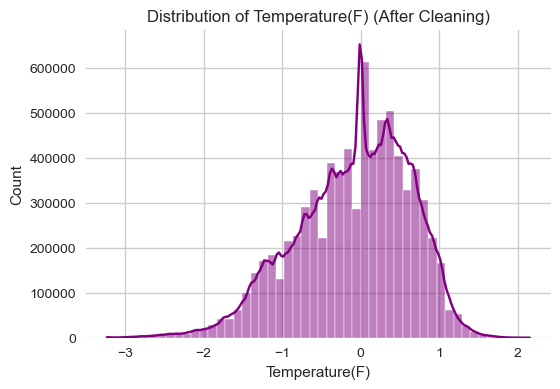

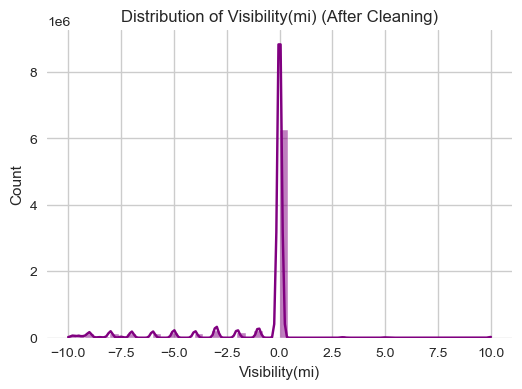

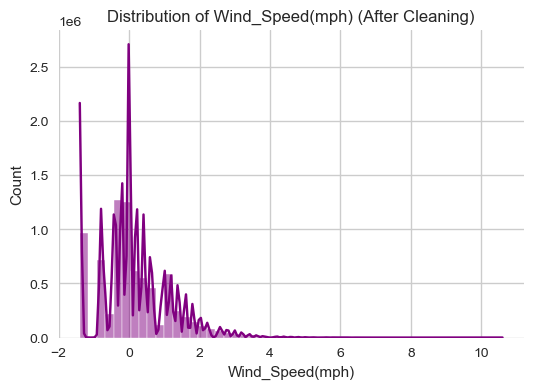

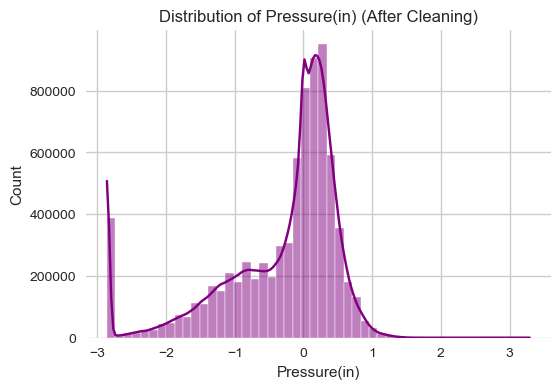

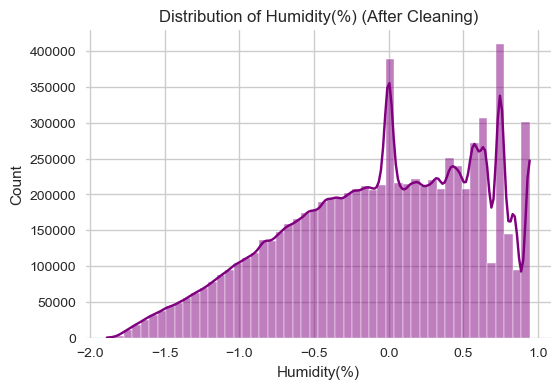

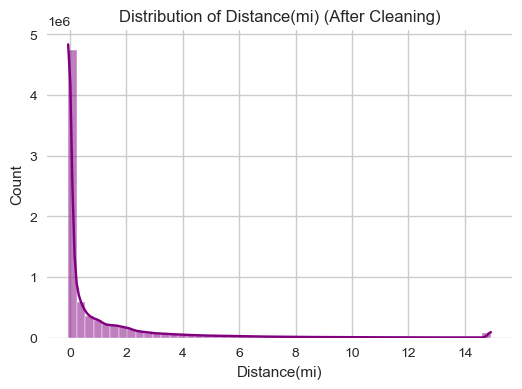

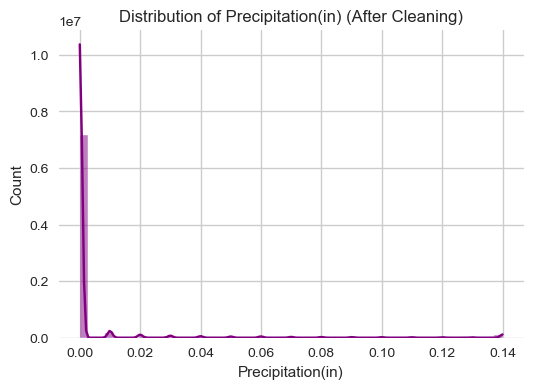

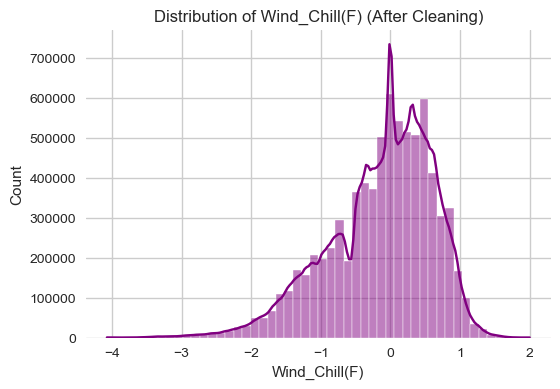

In [32]:
for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_scale[col], bins=50, kde=True,color='purple')
    plt.title(f"Distribution of {col} (After Cleaning)")
    plt.show()

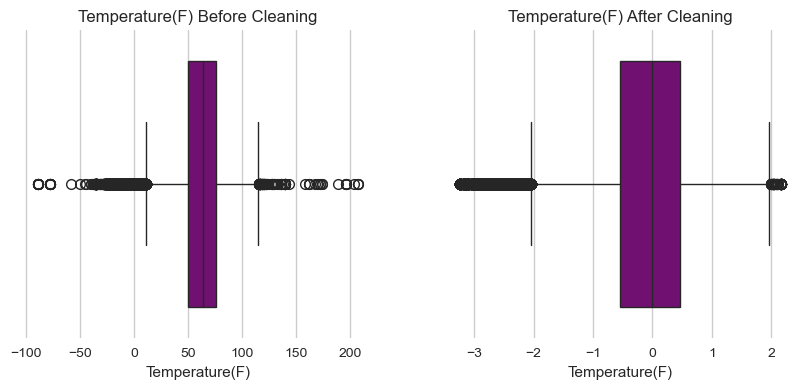

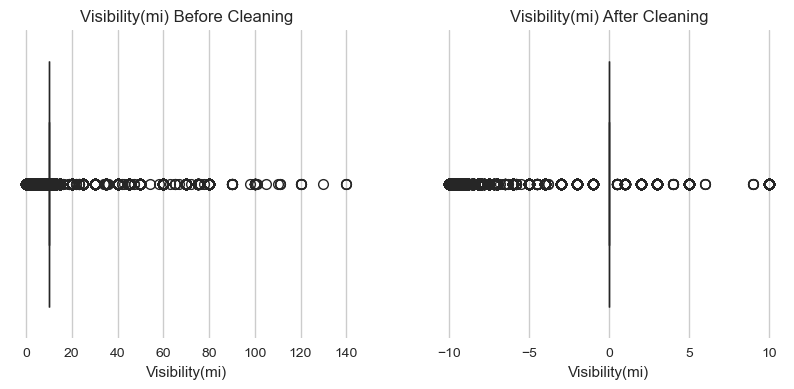

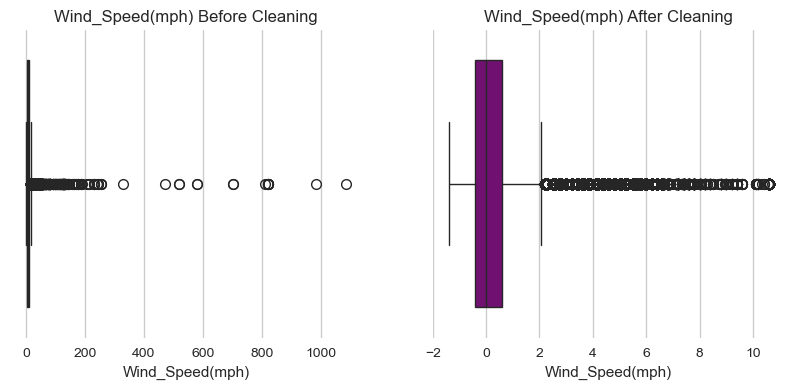

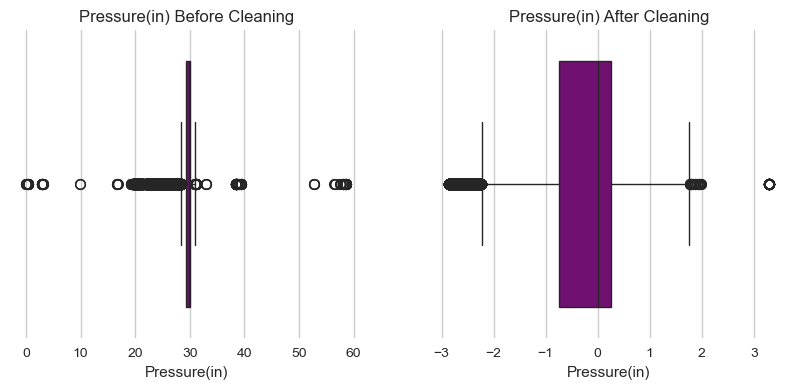

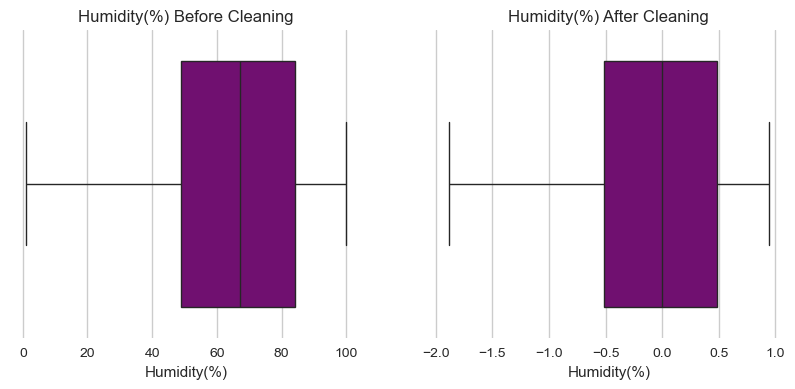

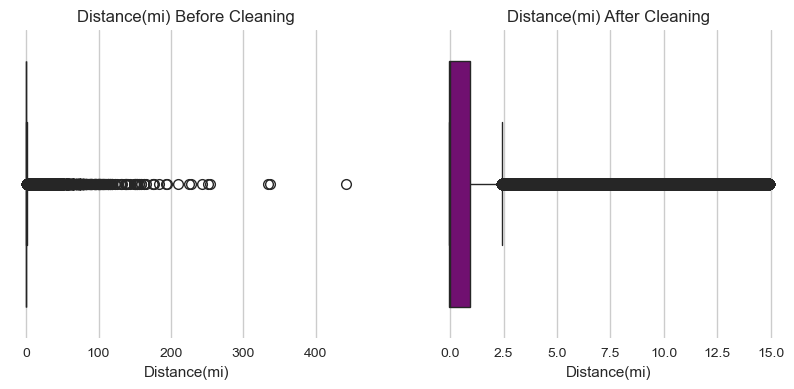

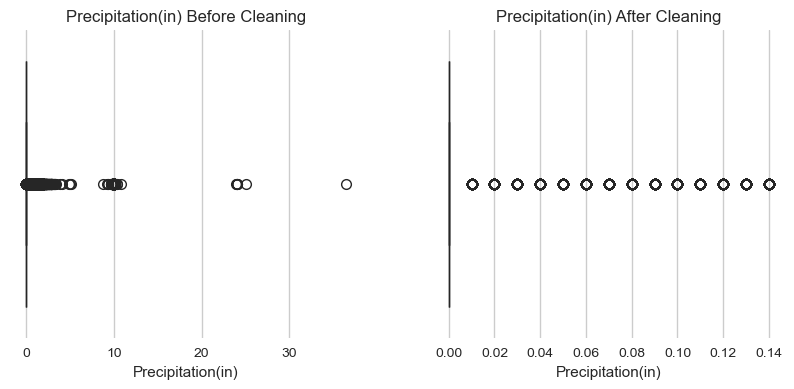

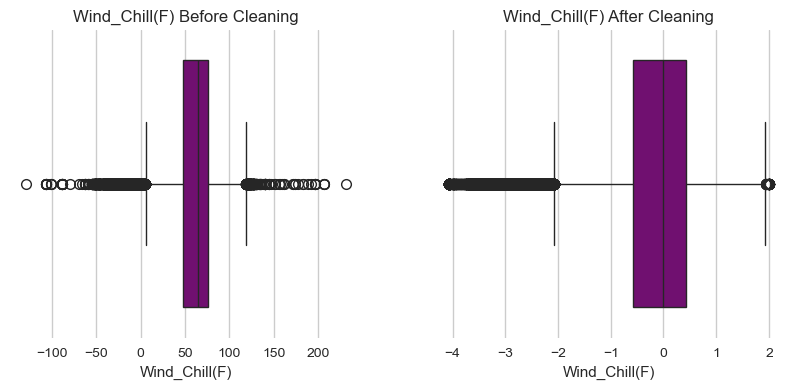

In [33]:
for col in cols:

    fig, axes = plt.subplots(1,2, figsize=(10,4))

    sns.boxplot(x=df[col], ax=axes[0],color='purple')
    axes[0].set_title(f"{col} Before Cleaning")

    sns.boxplot(x=df_scale[col], ax=axes[1],color='purple')
    axes[1].set_title(f"{col} After Cleaning")

    plt.show()

In [34]:
df_clean.head(5)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Start_Date,Start_Time_new,End_Date,End_Time_New,Start_Time_only,End_Time_only,Hour_Start,Minutes_Start,Hour_End,Minutes_End,Day_of_Week,Month,Year,Accident_Duration_Hours,Duration_Hours,Duration_Minutes,Rush_Hour
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.9,31.401920,91.0,29.68,10.0,Calm,7.0,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2016-02-08,2026-03-27 05:46:00,2016-02-08,2026-03-27 11:00:00,05:46:00,11:00:00,5,46,11,0,0,2,2016,0 days 05:14:00,5.23,314.0,0
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.9,32.607069,100.0,29.65,10.0,Calm,7.0,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day,2016-02-08,2026-03-27 06:07:59,2016-02-08,2026-03-27 06:37:59,06:07:59,06:37:59,6,7,6,37,0,2,2016,0 days 00:30:00,0.50,30.0,0
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.0,33.300000,100.0,29.67,10.0,SW,3.5,0.00,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day,2016-02-08,2026-03-27 06:49:27,2016-02-08,2026-03-27 07:19:27,06:49:27,07:19:27,6,49,7,19,0,2,2016,0 days 00:30:00,0.50,30.0,0
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.1,31.000000,96.0,29.64,9.0,SW,4.6,0.00,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day,2016-02-08,2026-03-27 07:23:34,2016-02-08,2026-03-27 07:53:34,07:23:34,07:53:34,7,23,7,53,0,2,2016,0 days 00:30:00,0.50,30.0,1
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.0,33.300000,89.0,29.65,6.0,SW,3.5,0.00,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day,2016-02-08,2026-03-27 07:39:07,2016-02-08,2026-03-27 08:09:07,07:39:07,08:09:07,7,39,8,9,0,2,2016,0 days 00:30:00,0.50,30.0,1


In [35]:
# List of columns to drop
cols_to_drop = [
    'ID', 'Source', 'Description', 'Zipcode', 'Airport_Code', 'Country', 'Number',
    'Precipitation(in)_new', 'Weather_Timestamp', 'Start_Time', 'End_Time', 'End_Lat', 'End_Lng',
    'Start_Date', 'Start_Time_new', 'End_Date', 'Accident_Duration_Hours', 'End_Time_New', 'Start_Time_only', 'End_Time_only',
    'Street'
]

# Drop columns only if they exist in df
cols_to_drop = [col for col in cols_to_drop if col in df.columns]

# Create cleaned dataframe without modifying the original df
df_clean.drop(columns=cols_to_drop,axis=1,inplace=True)

print(f"After drop, df_clean shape: {df_clean.shape}")
df_clean.head()

After drop, df_clean shape: (7728394, 44)


,Severity,Start_Lat,Start_Lng,Distance(mi),City,County,State,Timezone,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Hour_Start,Minutes_Start,Hour_End,Minutes_End,Day_of_Week,Month,Year,Duration_Hours,Duration_Minutes,Rush_Hour
0,3,39.865147,-84.058723,0.01,Dayton,Montgomery,OH,US/Eastern,36.9,31.401920,91.0,29.68,10.0,Calm,7.0,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night,5,46,11,0,0,2,2016,5.23,314.0,0
1,2,39.928059,-82.831184,0.01,Reynoldsburg,Franklin,OH,US/Eastern,37.9,32.607069,100.0,29.65,10.0,Calm,7.0,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day,6,7,6,37,0,2,2016,0.50,30.0,0
2,2,39.063148,-84.032608,0.01,Williamsburg,Clermont,OH,US/Eastern,36.0,33.300000,100.0,29.67,10.0,SW,3.5,0.00,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day,6,49,7,19,0,2,2016,0.50,30.0,0
3,3,39.747753,-84.205582,0.01,Dayton,Montgomery,OH,US/Eastern,35.1,31.000000,96.0,29.64,9.0,SW,4.6,0.00,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day,7,23,7,53,0,2,2016,0.50,30.0,1
4,2,39.627781,-84.188354,0.01,Dayton,Montgomery,OH,US/Eastern,36.0,33.300000,89.0,29.65,6.0,SW,3.5,0.00,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day,7,39,8,9,0,2,2016,0.50,30.0,1


In [36]:
 df_clean.to_csv('Clean_Version_Accident.csv')